In [1]:
import mdtraj as md
import h5py
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from scipy.stats import gaussian_kde

plt.style.use("rotskoff_cmap")

Bad value in file PosixPath('/home/ethanz/boltz-likelihoods/.venv/lib/python3.12/site-packages/matplotlib/mpl-data/stylelib/rotskoff_cmap.mplstyle'), line 18 ('axes.prop_cycle: cycler("color", [\'#00386b\', \'#00679f\', \'#1b9ad0\', \'#54cffb\', \'#fbac41\', \'#fa8f34\', \'#f87026\', \'#f54b1a\'])'): Key axes.prop_cycle: 'cycler("color", [\'' is not a valid cycler construction: unterminated string literal (detected at line 1) (<unknown>, line 1)
Bad value in file PosixPath('/home/ethanz/.config/matplotlib/stylelib/rotskoff_cmap.mplstyle'), line 18 ('axes.prop_cycle: cycler("color", [\'#00386b\', \'#00679f\', \'#1b9ad0\', \'#54cffb\', \'#fbac41\', \'#fa8f34\', \'#f87026\', \'#f54b1a\'])'): Key axes.prop_cycle: 'cycler("color", [\'' is not a valid cycler construction: unterminated string literal (detected at line 1) (<unknown>, line 1)


In [ ]:
# # Loading in data.
# # GT Traj.
# GT_TOP_PATH = '/home/ethanz/data_boltz_likelihood/md/chignolin.pdb'
# GT_TRAJ_PATH = '/home/ethanz/data_boltz_likelihood/md/chignolin_traj_all.hdf5'

# chignolin_traj_xyz = h5py.File(GT_TRAJ_PATH, 'r')['positions'][:] # In nm already.
# chignolin_traj_full = md.Trajectory(xyz=chignolin_traj_xyz / 10, topology=md.load(GT_TOP_PATH).topology)

In [4]:
# Loading in data.
mdt_top = md.load('/data2/scratch/ethanz/data_boltz_likelihood/md/chignolin_folded.pdb').topology

# GT (OMM unbiased) Traj.
mdt_chignolin_unbiased_traj = md.load('chignolin_unbiased.dcd', top=mdt_top)
mdt_chignolin_unbiased_traj_final = mdt_chignolin_unbiased_traj[::20].superpose(mdt_chignolin_unbiased_traj[0])
print(mdt_chignolin_unbiased_traj_final.n_frames) # 200 ns in total, 1000 frames --> each frame is 200 ps.

# GT (OMM unbiased) Traj.
mdt_chignolin_mtd_traj = md.load('chignolin_mtd.dcd', top=mdt_top)
mdt_chignolin_mtd_traj_final = mdt_chignolin_mtd_traj[::20].superpose(mdt_chignolin_mtd_traj[0])
print(mdt_chignolin_mtd_traj_final.n_frames) # 10 ns in total, 50 frames --> each frame is 200 ps.

# Truncate them to same length - mtd didn't finish
mdt_chignolin_unbiased_traj_final = mdt_chignolin_unbiased_traj_final[:750]
mdt_chignolin_mtd_traj_final = mdt_chignolin_mtd_traj_final[:750]

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
1000
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) Warning: DCD header claims 17341 frames, but 
dcdplugin) file size (36828832) indicates there are actually 
17340 frames of size (2124)
867


In [5]:
# Saving trajs.
mdt_chignolin_unbiased_traj_final.save('/home/ethanz/boltz-likelihoods/SPLASH/chignolin_unbiased.pdb')
mdt_chignolin_mtd_traj_final.save('/home/ethanz/boltz-likelihoods/SPLASH/chignolin_mtd.pdb')

### Length plot animation of GT traj.

In [ ]:
# # Seaborn styling
# fig, ax = plt.subplots(figsize=(10, 6))

# palette_5 = sns.color_palette("blend:#f2e7c9,#247891", n_colors=5)
# palette_cmap = sns.color_palette("blend:#f2e7c9,#247891", as_cmap=True)
# legend_color = "#8F97A6"
# backdrop_color = "#1C1F26"
# outer_color = "#EDE5DD"

# title_size = 22
# label_size = 18
# subtitle_size = 18
# tick_size = 14
# legend_size = 14

# def set_tick_params(axes):
#     axes = np.atleast_1d(axes)  # ensures iterable
    
#     for ax in axes.flat:
#         ax.tick_params(
#             axis='both', which='both',
#             direction='out', length=6, width=1.5,
#             colors='black', labelsize=tick_size
#         )

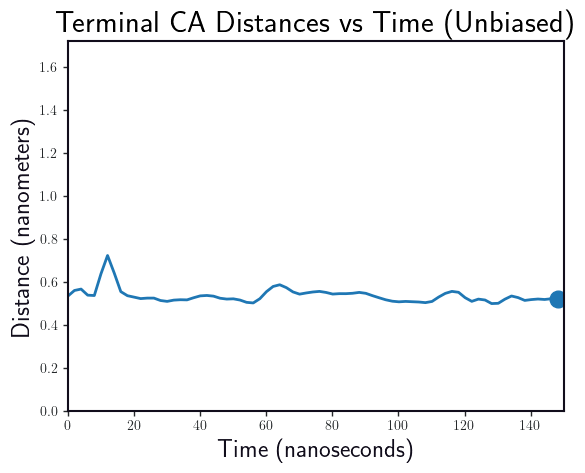

In [7]:
title_size = 22
label_size = 18
subtitle_size = 18
tick_size = 14
legend_size = 14

def smooth_with_kde(y: np.ndarray, bandwidth: float = 1.0) -> np.ndarray:
    x = np.arange(len(y))
    smoothed = np.zeros_like(y, dtype=float)

    for i, xi in enumerate(x):
        weights = np.exp(-0.5 * ((x - xi) / bandwidth) ** 2)
        weights /= weights.sum()
        smoothed[i] = np.sum(weights * y)

    return smoothed

traj = mdt_chignolin_unbiased_traj_final

backbone = traj.topology.select('backbone')
ca_indices = traj.topology.select("name CA")
i = ca_indices[0]
j = ca_indices[-1]

pairs = np.array([[i, j]])
distances = md.compute_distances(traj, pairs).squeeze(1) # In nanometers. 
# 200 ps per frame, 150 ns total.
timesteps = np.linspace(0, 150, num=len(distances)) # In nanoseconds.

# TODO: change back once finished testing.
distances = distances[::10]
timesteps = timesteps[::10]

# (Optional) KDE for smooth curve.
distances = smooth_with_kde(distances)

# Animation code.
fig = plt.figure()
plt.xlim(0, 150)
plt.ylim(0, distances.max() + 1)
plt.xlabel('Time (nanoseconds)')
plt.ylabel('Distance (nanometers)')
plt.title('Terminal CA Distances vs Time (Unbiased)', fontsize=title_size)

# Plot objects we'll update each frame
line, = plt.plot([], [], lw=2)
line_color = line.get_color()
point, = plt.plot([], [], 'o', markersize=12, color=line_color)

def init():
    line.set_data([], [])
    point.set_data([], [])
    return line, point

def update(frame):
    # Grow the line up to the current frame index
    x = timesteps[:frame]
    y = distances[:frame]
    line.set_data(x, y)
    if frame > 0:
        point.set_data([timesteps[frame - 1]], [distances[frame - 1]])
    return line, point

ani = animation.FuncAnimation(
    fig, 
    update, 
    frames=len(timesteps) + 1, 
    init_func=init, 
    blit=True, 
    repeat=False
)

# Save animation as GIF
ani.save('/home/ethanz/boltz-likelihoods/SPLASH/unbiased_distance_animation.gif', writer='pillow', fps=30, dpi=100)

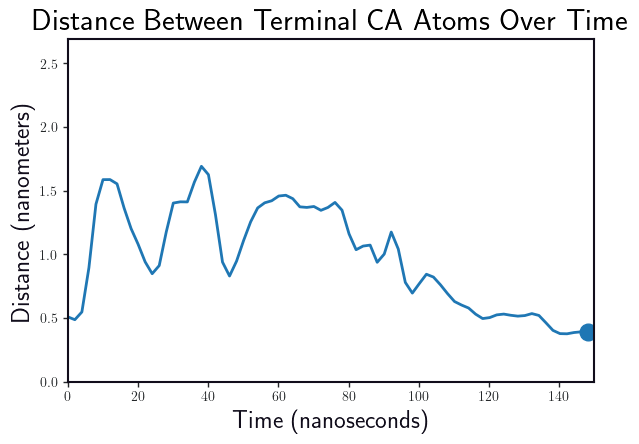

In [8]:
traj = mdt_chignolin_mtd_traj_final

backbone = traj.topology.select('backbone')
ca_indices = traj.topology.select("name CA")
i = ca_indices[0]
j = ca_indices[-1]

pairs = np.array([[i, j]])
distances = md.compute_distances(traj, pairs).squeeze(1) # In nanometers. 
# 200 ps per frame, 150 ns total.
timesteps = np.linspace(0, 150, num=len(distances)) # In nanoseconds.

# TODO: change back once finished testing.
distances = distances[::10]
timesteps = timesteps[::10]

# (Optional) KDE for smooth curve.
distances = smooth_with_kde(distances)

# Animation code.
fig = plt.figure()
plt.xlim(0, 150)
plt.ylim(0, distances.max() + 1)
plt.xlabel('Time (nanoseconds)')
plt.ylabel('Distance (nanometers)')
plt.title('Distance Between Terminal CA Atoms Over Time', fontsize=title_size)

# Plot objects we'll update each frame
line, = plt.plot([], [], lw=2)
line_color = line.get_color()
point, = plt.plot([], [], 'o', markersize=12, color=line_color)

def init():
    line.set_data([], [])
    point.set_data([], [])
    return line, point

def update(frame):
    # Grow the line up to the current frame index
    x = timesteps[:frame]
    y = distances[:frame]
    line.set_data(x, y)
    if frame > 0:
        point.set_data([timesteps[frame - 1]], [distances[frame - 1]])
    return line, point

ani = animation.FuncAnimation(fig, update, frames=len(timesteps) + 1, init_func=init, blit=True, repeat=False)
plt.tight_layout(pad=2.0)  # increase padding

# Save animation as GIF
ani.save('/home/ethanz/boltz-likelihoods/SPLASH/mtd_distance_animation.gif', writer='pillow', fps=120, dpi=100)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def check_convergence_by_windows(meta, simulation, window_steps, n_windows, bias_variable):
    """
    Run simulation in windows, saving FES at each window.
    """
    fes_snapshots = []
    
    for i in range(n_windows):
        meta.step(simulation, window_steps)
        fes = np.array(meta.getFreeEnergy())
        fes -= fes.min()  # Zero-reference
        fes_snapshots.append(fes)
        print(f"Window {i+1}/{n_windows} done")
    
    return fes_snapshots

def plot_fes_convergence(fes_snapshots, bias_variable):
    """
    Overlay FES from each window — visual convergence check.
    """
    cv_min, cv_max = bias_variable.minValue, bias_variable.maxValue
    n_points = len(fes_snapshots[0])
    cv_values = np.linspace(cv_min, cv_max, n_points)
    
    plt.figure(figsize=(8, 5))
    cmap = plt.cm.viridis(np.linspace(0, 1, len(fes_snapshots)))
    for i, fes in enumerate(fes_snapshots):
        plt.plot(cv_values, fes, color=cmap[i], 
                 label=f"t={i+1}", alpha=0.8)
    plt.xlabel("End-to-end distance (nm)")
    plt.ylabel("Free Energy (kJ/mol)")
    plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), label='Time window')
    plt.title("FES convergence over time")
    plt.tight_layout()
    plt.savefig("fes_convergence.png", dpi=150)
    plt.show()



In [ ]:
# Trying to save a smoothed trajectory.
backbone = chignolin_traj_full.topology.select('backbone')
chignolin_traj = chignolin_traj_full[::2000].superpose(chignolin_traj_full[0], atom_indices=backbone)
chignolin_traj = chignolin_traj.smooth(width=5, order=3)
chignolin_traj = chignolin_traj_full.center_coordinates().superpose(chignolin_traj_full[0], atom_indices=backbone).smooth(width=5, order=3, atom_indices=backbone)
chignolin_traj.save('/home/ethanz/boltz-likelihoods/SPLASH/chignolin_traj.pdb')

chignolin_traj = chignolin_traj_full[::500].superpose(chignolin_traj_full[0], atom_indices=backbone)
chignolin_traj = chignolin_traj.smooth(width=5, order=3)
chignolin_traj = chignolin_traj[::4]
chignolin_traj.save('/home/ethanz/boltz-likelihoods/SPLASH/chignolin_traj_test.pdb')

### Animated plot of end-to-end CA distance over time

In [31]:
palette_5 = sns.color_palette("blend:#f2e7c9,#247891", n_colors=5)
print(palette_5.as_hex())
palette_5.as_hex()

['#f2e7c9', '#becbbb', '#8bafad', '#57939f', '#247891']


['#f2e7c9', '#becbbb', '#8bafad', '#57939f', '#247891']

### Free energy plot of end-to-end length

In [55]:
T = 300 # TODO: verify
kB = 0.008314
kT = kB * T

x_grid = np.linspace(distances_all.min(), distances_all.max(), 500)
kde = gaussian_kde(distances_all[:, None], bw_method='scott')
p = kde(x_grid)
p = np.clip(p, 1e-10, None)  # Avoid log(0)
F = -kT * np.log(p)
F -= F.min()  # Set minimum to zero for better visualization
plt.show()

ValueError: Number of dimensions is greater than number of samples. This results in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Note that `gaussian_kde` interprets each *column* of `dataset` to be a point; consider transposing the input to `dataset`.